In [1]:
from utils import *

## Schematic figure

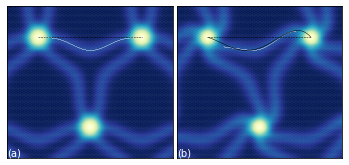

In [2]:
import matplotlib.gridspec as gridspec
colormap='YlGnBu_r'

ii=30
stacking = 'AP'
SIZE_PT  = 0.7
poly_deg = 4
spacing = 600
x1 = 'S'

gs1 = gridspec.GridSpec(1, 2)
gs1.update(wspace=0.025, hspace=0.05)

for h,(m1,m2) in enumerate([('Mo','Mo'),('Mo','W')]):

    if m1!=m2:
        x_stop = 0.15
    else:
        x_stop = 0

    data = np.load(f'grid_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.npz')
    # Access arrays and variables
    x_sc = data['x_sc']
    y_sc = data['y_sc']
    d_local_sc = data['d_local_sc']
    
    ## prepare plotting
    # initialize plot object
    ax = plt.subplot(gs1[h])
    # add scatterplot of interlayer distance
    im = ax.scatter(x_sc, y_sc, c=d_local_sc, s=SIZE_PT,cmap=colormap) # scatter data

    # args_min_d = np.where(d_local_sc==min(d_local_sc))[0]
    args_max_d = np.where(d_local_sc==max(d_local_sc))[0]

    xs_max_d = x_sc[args_max_d]
    ys_max_d = y_sc[args_max_d]
    
    i=10

    points = np.column_stack((xs_max_d,ys_max_d))
    distances = cdist(points,points)[i]
    nn1_dist = np.unique(np.round(distances,10))[1] ##Get first nearest neighbours of node
    nn1s = np.where(np.round(distances,10) == nn1_dist)[0]
    nn1_arg_1 = nn1s[np.where((xs_max_d[nn1s]<xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
    nn1_arg_2 = nn1s[np.where((xs_max_d[nn1s]>xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
    x_sol1,x_sol2,x_sol3 = xs_max_d[[i,nn1_arg_1,nn1_arg_2]]
    y_sol1,y_sol2,y_sol3 = ys_max_d[[i,nn1_arg_1,nn1_arg_2]]
    x_cent,y_cent = (x_sol1+x_sol2+x_sol3)/3,(y_sol1+y_sol2+y_sol3)/3

    xs = np.linspace(x_sol2,x_sol3)
    ys = y_sol2*np.ones(len(xs))
    plt.plot(xs,ys,c='k',lw=0.5,linestyle='--')


    x_min,x_max = x_cent,x_sol3-x_stop*nn1_dist
    y_min,y_max = y_cent+0.1*nn1_dist,y_sol3+0.1*nn1_dist
    x_23_right,y_23_right = get_max_ds(x_sc,y_sc,d_local_sc,x_min,x_max,
                      y_min,y_max,True,spacing=int(spacing*(x_max-x_min)/nn1_dist))

    x_min,x_max = x_sol2+x_stop*nn1_dist,x_cent 
    y_min,y_max = y_cent+0.1*nn1_dist,y_sol2
    x_23_left,y_23_left = get_max_ds(x_sc,y_sc,d_local_sc,x_min,x_max,
                      y_min,y_max,True,spacing=int(spacing*(x_max-x_min)/nn1_dist))

    xdata = np.concatenate(([x_sol2],x_23_left,x_23_right,[x_sol3]))
    ydata = np.concatenate(([y_sol2],y_23_left,y_23_right,[y_sol3]))

    plt.scatter(xdata,ydata,s=0.001,c='w')#,facecolors='none')

    if m1!=m2:
        weights = np.ones(len(xdata))
        weights[0],weights[-1]=100,100
        poly = np.polyfit(xdata,ydata,w=weights,deg=poly_deg)
        poly_deriv = np.polyder(poly)
        x_23 = np.linspace(x_sol2,x_sol3,spacing)
        y_23 = np.polyval(poly,x_23)
        plt.plot(x_23,y_23,c='k',lw=0.5)

    x_lim_low = x_sol2-0.3*nn1_dist
    x_lim_high = x_sol3+0.3*nn1_dist
    y_lim_low = y_sol1-0.3*nn1_dist
    y_lim_high = y_sol2+0.3*nn1_dist
    
    ax.set_xlim(x_lim_low,x_lim_high)
    ax.set_ylim(y_lim_low,y_lim_high)

    # remove ticks for x and y axis
    ax.get_xaxis().set_ticks([]) # don't show x-axis ticks
    ax.get_yaxis().set_ticks([]) # don't show y-axis ticks
    ax.set_aspect('equal')
    ax.text(x_lim_low,y_lim_low,f"({chr(ord('a')+h)})",fontsize=10,va='bottom',ha='left',color='white')
    
# save plot and finish

plt.savefig('domain_ratio_schematic.png',dpi=300,facecolor='white',transparent=False,
            bbox_inches='tight',pad_inches=0.02)
plt.show()

# Plot with error analysis

In [5]:
from matplotlib.patches import Arc

colormap='YlGnBu_r'
stacking = 'AP'
SIZE_PT = 4 
ratios_dict = {}
poly_degs = np.array([4,5])
spacing_factors = np.linspace(0.07,0.2,10)

for stacking in ['AP']:
    if stacking =='P':
        mpairs = [('Mo','W')]
    else:
        mpairs = [('Mo','Mo'),('Mo','W')]
            
    for m1,m2 in mpairs:
            
        for x1 in ['S','Se']:
            
            if stacking=='AP': 
                if m1==m2 or x1=='Se':
                    iis=[10,12,15,16,18,20,22,25,27,30,40]
                else:
                    iis=[10,12,15,16,18,20,22,25,27,30]
            else:
                iis=[16,18,20,22,25,27,30]
            
            print(f'Starting calculations for {stacking}-{m1}{x1}2/{m2}{x1}2...')
            
            if m1!=m2:
                x_stops = np.array([0.15,0.175,0.2])
                ratios = np.zeros((len(iis),len(spacing_factors)*len(x_stops)*len(poly_degs)))
            else:
                x_stops = np.array([0.0])
                ratios = np.zeros((len(iis),len(spacing_factors)))
            
            
            for num_ii,ii in enumerate(iis):
                print(f'ii={ii}')
                
                if ii in [10,12]:
                    data = np.load(f'grid_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}_hres.npz')
                else:
                    data = np.load(f'grid_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.npz')
                x_sc = data['x_sc']
                y_sc = data['y_sc']
                d_local_sc = data['d_local_sc']

                # args_min_d = np.where(d_local_sc==min(d_local_sc))[0]
                args_max_d = np.where(d_local_sc==max(d_local_sc))[0]
                xs_max_d = x_sc[args_max_d]
                ys_max_d = y_sc[args_max_d]

                i=50

                points = np.column_stack((xs_max_d,ys_max_d))
                distances = cdist(points,points)[i]
                nn1_dist = np.unique(np.round(distances,10))[1] ##Get first nearest neighbours of node
                nn1s = np.where(np.round(distances,10) == nn1_dist)[0]
                nn1_arg_1 = nn1s[np.where((xs_max_d[nn1s]<xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
                nn1_arg_2 = nn1s[np.where((xs_max_d[nn1s]>xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
                x_sol1,x_sol2,x_sol3 = xs_max_d[[i,nn1_arg_1,nn1_arg_2]]
                y_sol1,y_sol2,y_sol3 = ys_max_d[[i,nn1_arg_1,nn1_arg_2]]
                x_cent,y_cent = (x_sol1+x_sol2+x_sol3)/3,(y_sol1+y_sol2+y_sol3)/3
                
                m=0
                
                if m1==m2 or ii<15:
                    x_stops = np.array([0.0])
                elif m1!=m2 and ii==40:
                    x_stops = np.array([0.2,0.225,0.25])
                else:
                    x_stops = np.array([0.15,0.175,0.2])   
                
                
                for j,spacing_factor in enumerate(spacing_factors):
                    
                    for k,x_stop in enumerate(x_stops):
                        
                        spacing = int(nn1_dist/spacing_factor)//2    
                                        
                        x_min,x_max = x_cent,x_sol3-x_stop*nn1_dist                        
                        y_min,y_max = y_cent+0.1*nn1_dist,y_sol3+0.1*nn1_dist
                        x_23_right,y_23_right = get_max_ds(x_sc,y_sc,d_local_sc,x_min,x_max,
                                          y_min,y_max,True,spacing=spacing)

                        x_min,x_max = x_sol2+x_stop*nn1_dist,x_cent
                        y_min,y_max = y_cent+0.1*nn1_dist,y_sol2
                        x_23_left,y_23_left = get_max_ds(x_sc,y_sc,d_local_sc,x_min,x_max,
                                          y_min,y_max,True,spacing=spacing)
                        
                        xdata = np.concatenate(([x_sol2],x_23_left,x_23_right,[x_sol3]))
                        ydata = np.concatenate(([y_sol2],y_23_left,y_23_right,[y_sol3]))
                        
                        if len(x_stops)==1:
                            
                            area_reduced = abs(np.trapz(ydata,x=xdata)-y_sol2*(x_sol3-x_sol2))
                            area_triangle = ((x_sol3-x_sol2)**2)*(3**0.5)/4
                            area_domain_MM = area_triangle-3*area_reduced
                            area_domain_2H = area_triangle+3*area_reduced
                            domain_ratio = area_domain_MM/area_domain_2H
                            #print(area_reduced,area_triangle,2*area_triangle,area_domain_MM,area_domain_2H,domain_ratio)
                            ratios[num_ii][m] = domain_ratio
                            print(f'spacing={spacing}, x_stop={x_stop}, ratio={domain_ratio}')
                            m+=1
                        else:
                            
                            for l,poly_deg in enumerate(poly_degs):
                                
                                weights = np.ones(len(xdata))
                                weights[0],weights[-1]=100,100
                                poly = np.polyfit(xdata,ydata,w=weights,deg=poly_deg)
                                x_23 = np.linspace(x_sol2,x_sol3,1000)
                                y_23 = np.polyval(poly,x_23)
                                area_reduced = abs(np.trapz(y_23,x=x_23)-y_sol2*(x_sol3-x_sol2))
                                area_triangle = ((x_sol3-x_sol2)**2)*(3**0.5)/4
                                area_domain_MM = area_triangle-3*area_reduced
                                area_domain_2H = area_triangle+3*area_reduced
                                domain_ratio = area_domain_MM/area_domain_2H
                                #print(area_reduced,area_triangle,2*area_triangle,area_domain_MM,area_domain_2H,domain_ratio)
                                ratios[num_ii][m] = domain_ratio
                                print(f'spacing={spacing}, x_stop={x_stop}, poly_deg={poly_deg}, ratio={domain_ratio}')
                                m+=1
            ratios_dict[f'{stacking}-{m1}{m2}{x1}'] = ratios.copy()


Starting calculations for AP-MoS2/MoS2...
ii=10
spacing=414, x_stop=0.0, ratio=0.9808224449632768
spacing=343, x_stop=0.0, ratio=0.9803826255497168
spacing=293, x_stop=0.0, ratio=0.9805830795839815
spacing=255, x_stop=0.0, ratio=0.9802731643887299
spacing=226, x_stop=0.0, ratio=0.9801046110889656
spacing=203, x_stop=0.0, ratio=0.98117984226689
spacing=185, x_stop=0.0, ratio=0.9802652315891375
spacing=169, x_stop=0.0, ratio=0.9805355531144326
spacing=156, x_stop=0.0, ratio=0.9794958788001876
spacing=144, x_stop=0.0, ratio=0.9811676731481581
ii=12
spacing=492, x_stop=0.0, ratio=0.9312252083655025
spacing=408, x_stop=0.0, ratio=0.9313329606784772
spacing=348, x_stop=0.0, ratio=0.9311669466643945
spacing=304, x_stop=0.0, ratio=0.9305600827825897
spacing=270, x_stop=0.0, ratio=0.9314026717895465
spacing=242, x_stop=0.0, ratio=0.9309165395296274
spacing=220, x_stop=0.0, ratio=0.9304836411139228
spacing=201, x_stop=0.0, ratio=0.9313937344426407
spacing=185, x_stop=0.0, ratio=0.932315859671254

spacing=698, x_stop=0.0, ratio=0.4732380567282032
spacing=596, x_stop=0.0, ratio=0.47322094855059793
spacing=520, x_stop=0.0, ratio=0.47324041980507886
spacing=461, x_stop=0.0, ratio=0.47322834211059583
spacing=414, x_stop=0.0, ratio=0.473229747466806
spacing=376, x_stop=0.0, ratio=0.47330003957006983
spacing=344, x_stop=0.0, ratio=0.4733261891216212
spacing=317, x_stop=0.0, ratio=0.4731726742964368
spacing=294, x_stop=0.0, ratio=0.47318574093307053
ii=22
spacing=924, x_stop=0.0, ratio=0.437714621789959
spacing=766, x_stop=0.0, ratio=0.4376954030473178
spacing=654, x_stop=0.0, ratio=0.43770329649731543
spacing=571, x_stop=0.0, ratio=0.43771595965198684
spacing=506, x_stop=0.0, ratio=0.4376651748962442
spacing=455, x_stop=0.0, ratio=0.4377049525000069
spacing=413, x_stop=0.0, ratio=0.4376978437885567
spacing=378, x_stop=0.0, ratio=0.43762892996805
spacing=348, x_stop=0.0, ratio=0.4377392161612483
spacing=323, x_stop=0.0, ratio=0.43765227967114123
ii=25
spacing=1048, x_stop=0.0, ratio=0.

spacing=539, x_stop=0.15, poly_deg=4, ratio=0.8314616667497525
spacing=539, x_stop=0.15, poly_deg=5, ratio=0.8314616667504039
spacing=539, x_stop=0.175, poly_deg=4, ratio=0.8277497042160279
spacing=539, x_stop=0.175, poly_deg=5, ratio=0.8277497042143757
spacing=539, x_stop=0.2, poly_deg=4, ratio=0.8222186292871865
spacing=539, x_stop=0.2, poly_deg=5, ratio=0.8222186292882091
spacing=460, x_stop=0.15, poly_deg=4, ratio=0.831439034112725
spacing=460, x_stop=0.15, poly_deg=5, ratio=0.831439034111407
spacing=460, x_stop=0.175, poly_deg=4, ratio=0.8276810331085867
spacing=460, x_stop=0.175, poly_deg=5, ratio=0.8276810331049378
spacing=460, x_stop=0.2, poly_deg=4, ratio=0.8222501150903935
spacing=460, x_stop=0.2, poly_deg=5, ratio=0.8222501150896429
spacing=402, x_stop=0.15, poly_deg=4, ratio=0.831526330157593
spacing=402, x_stop=0.15, poly_deg=5, ratio=0.8315263301571554
spacing=402, x_stop=0.175, poly_deg=4, ratio=0.8278667302126049
spacing=402, x_stop=0.175, poly_deg=5, ratio=0.8278667302

spacing=499, x_stop=0.15, poly_deg=4, ratio=0.7513703953945257
spacing=499, x_stop=0.15, poly_deg=5, ratio=0.7513703954028079
spacing=499, x_stop=0.175, poly_deg=4, ratio=0.7486747914166378
spacing=499, x_stop=0.175, poly_deg=5, ratio=0.7486747914155829
spacing=499, x_stop=0.2, poly_deg=4, ratio=0.7601302279130895
spacing=499, x_stop=0.2, poly_deg=5, ratio=0.7601302279133849
spacing=443, x_stop=0.15, poly_deg=4, ratio=0.7514557848205199
spacing=443, x_stop=0.15, poly_deg=5, ratio=0.751455784819561
spacing=443, x_stop=0.175, poly_deg=4, ratio=0.7486864643978176
spacing=443, x_stop=0.175, poly_deg=5, ratio=0.7486864644022542
spacing=443, x_stop=0.2, poly_deg=4, ratio=0.7601382671834083
spacing=443, x_stop=0.2, poly_deg=5, ratio=0.760138267182583
spacing=398, x_stop=0.15, poly_deg=4, ratio=0.7519523770494907
spacing=398, x_stop=0.15, poly_deg=5, ratio=0.7519523770535275
spacing=398, x_stop=0.175, poly_deg=4, ratio=0.7487469867439488
spacing=398, x_stop=0.175, poly_deg=5, ratio=0.748746986

spacing=551, x_stop=0.2, poly_deg=4, ratio=0.6823472060998412
spacing=551, x_stop=0.2, poly_deg=5, ratio=0.6823472060998448
spacing=495, x_stop=0.15, poly_deg=4, ratio=0.6530824745208238
spacing=495, x_stop=0.15, poly_deg=5, ratio=0.6530824745208308
spacing=495, x_stop=0.175, poly_deg=4, ratio=0.6667030710015022
spacing=495, x_stop=0.175, poly_deg=5, ratio=0.6667030710015163
spacing=495, x_stop=0.2, poly_deg=4, ratio=0.6823652408370633
spacing=495, x_stop=0.2, poly_deg=5, ratio=0.6823652408371028
spacing=449, x_stop=0.15, poly_deg=4, ratio=0.6530495826678111
spacing=449, x_stop=0.15, poly_deg=5, ratio=0.6530495826678077
spacing=449, x_stop=0.175, poly_deg=4, ratio=0.6666060385209921
spacing=449, x_stop=0.175, poly_deg=5, ratio=0.6666060385210308
spacing=449, x_stop=0.2, poly_deg=4, ratio=0.6823028677753744
spacing=449, x_stop=0.2, poly_deg=5, ratio=0.6823028677753852
spacing=411, x_stop=0.15, poly_deg=4, ratio=0.65320028382744
spacing=411, x_stop=0.15, poly_deg=5, ratio=0.6532002838274

spacing=537, x_stop=0.175, poly_deg=4, ratio=0.5707260530009781
spacing=537, x_stop=0.175, poly_deg=5, ratio=0.5707260529939361
spacing=537, x_stop=0.2, poly_deg=4, ratio=0.5852260379008652
spacing=537, x_stop=0.2, poly_deg=5, ratio=0.5852260378691614
spacing=492, x_stop=0.15, poly_deg=4, ratio=0.5575669519043713
spacing=492, x_stop=0.15, poly_deg=5, ratio=0.5575669519340628
spacing=492, x_stop=0.175, poly_deg=4, ratio=0.5707014072258766
spacing=492, x_stop=0.175, poly_deg=5, ratio=0.5707014072196357
spacing=492, x_stop=0.2, poly_deg=4, ratio=0.5851601047211616
spacing=492, x_stop=0.2, poly_deg=5, ratio=0.5851601047042129
spacing=453, x_stop=0.15, poly_deg=4, ratio=0.5576075905694745
spacing=453, x_stop=0.15, poly_deg=5, ratio=0.557607590529871
spacing=453, x_stop=0.175, poly_deg=4, ratio=0.5707244172687415
spacing=453, x_stop=0.175, poly_deg=5, ratio=0.5707244172308074
spacing=453, x_stop=0.2, poly_deg=4, ratio=0.585214178000868
spacing=453, x_stop=0.2, poly_deg=5, ratio=0.58521417795

spacing=333, x_stop=0.175, poly_deg=4, ratio=0.5523622748717137
spacing=333, x_stop=0.175, poly_deg=5, ratio=0.5523622748717205
spacing=333, x_stop=0.2, poly_deg=4, ratio=0.5502050568753215
spacing=333, x_stop=0.2, poly_deg=5, ratio=0.5502050568750596
spacing=303, x_stop=0.15, poly_deg=4, ratio=0.5554860586394256
spacing=303, x_stop=0.15, poly_deg=5, ratio=0.5554860586389421
spacing=303, x_stop=0.175, poly_deg=4, ratio=0.5523727746356444
spacing=303, x_stop=0.175, poly_deg=5, ratio=0.5523727746357993
spacing=303, x_stop=0.2, poly_deg=4, ratio=0.5502289487175357
spacing=303, x_stop=0.2, poly_deg=5, ratio=0.5502289487171059
spacing=277, x_stop=0.15, poly_deg=4, ratio=0.5554231262178054
spacing=277, x_stop=0.15, poly_deg=5, ratio=0.5554231262178122
spacing=277, x_stop=0.175, poly_deg=4, ratio=0.5522785620779967
spacing=277, x_stop=0.175, poly_deg=5, ratio=0.5522785620784985
spacing=277, x_stop=0.2, poly_deg=4, ratio=0.5501485257746417
spacing=277, x_stop=0.2, poly_deg=5, ratio=0.550148525

spacing=344, x_stop=0.15, poly_deg=4, ratio=0.49346677502116737
spacing=344, x_stop=0.15, poly_deg=5, ratio=0.4934667750241315
spacing=344, x_stop=0.175, poly_deg=4, ratio=0.49602058163262436
spacing=344, x_stop=0.175, poly_deg=5, ratio=0.496020581633532
spacing=344, x_stop=0.2, poly_deg=4, ratio=0.5047746335421381
spacing=344, x_stop=0.2, poly_deg=5, ratio=0.504774633542708
spacing=317, x_stop=0.15, poly_deg=4, ratio=0.4934340295281167
spacing=317, x_stop=0.15, poly_deg=5, ratio=0.4934340295309192
spacing=317, x_stop=0.175, poly_deg=4, ratio=0.49592157291906086
spacing=317, x_stop=0.175, poly_deg=5, ratio=0.4959215729192371
spacing=317, x_stop=0.2, poly_deg=4, ratio=0.504791865470109
spacing=317, x_stop=0.2, poly_deg=5, ratio=0.5047918654690923
spacing=294, x_stop=0.15, poly_deg=4, ratio=0.4935912711865694
spacing=294, x_stop=0.15, poly_deg=5, ratio=0.49359127118728635
spacing=294, x_stop=0.175, poly_deg=4, ratio=0.49600763091288197
spacing=294, x_stop=0.175, poly_deg=5, ratio=0.49600

spacing=395, x_stop=0.2, poly_deg=4, ratio=0.45630395214897307
spacing=395, x_stop=0.2, poly_deg=5, ratio=0.4563039521490103
spacing=366, x_stop=0.15, poly_deg=4, ratio=0.42743680811954465
spacing=366, x_stop=0.15, poly_deg=5, ratio=0.42743680811954704
spacing=366, x_stop=0.175, poly_deg=4, ratio=0.4401110816482075
spacing=366, x_stop=0.175, poly_deg=5, ratio=0.44011108164820506
spacing=366, x_stop=0.2, poly_deg=4, ratio=0.4562991658147682
spacing=366, x_stop=0.2, poly_deg=5, ratio=0.45629916581477314
ii=27
spacing=1130, x_stop=0.15, poly_deg=4, ratio=0.40401540566045796
spacing=1130, x_stop=0.15, poly_deg=5, ratio=0.404015405659372
spacing=1130, x_stop=0.175, poly_deg=4, ratio=0.41750960387935687
spacing=1130, x_stop=0.175, poly_deg=5, ratio=0.41750960387869374
spacing=1130, x_stop=0.2, poly_deg=4, ratio=0.43286909786396094
spacing=1130, x_stop=0.2, poly_deg=5, ratio=0.4328690978597611
spacing=937, x_stop=0.15, poly_deg=4, ratio=0.40400164917079023
spacing=937, x_stop=0.15, poly_deg=5

spacing=1664, x_stop=0.225, poly_deg=4, ratio=0.3027913518018988
spacing=1664, x_stop=0.225, poly_deg=5, ratio=0.3027913518019697
spacing=1664, x_stop=0.25, poly_deg=4, ratio=0.3138100093696572
spacing=1664, x_stop=0.25, poly_deg=5, ratio=0.31381000936972697
spacing=1380, x_stop=0.2, poly_deg=4, ratio=0.2939470804956975
spacing=1380, x_stop=0.2, poly_deg=5, ratio=0.2939470804954598
spacing=1380, x_stop=0.225, poly_deg=4, ratio=0.3027896027934974
spacing=1380, x_stop=0.225, poly_deg=5, ratio=0.3027896027934344
spacing=1380, x_stop=0.25, poly_deg=4, ratio=0.3138034152436582
spacing=1380, x_stop=0.25, poly_deg=5, ratio=0.31380341524352684
spacing=1178, x_stop=0.2, poly_deg=4, ratio=0.2939485549630912
spacing=1178, x_stop=0.2, poly_deg=5, ratio=0.2939485549632954
spacing=1178, x_stop=0.225, poly_deg=4, ratio=0.30277911644317906
spacing=1178, x_stop=0.225, poly_deg=5, ratio=0.30277911644311684
spacing=1178, x_stop=0.25, poly_deg=4, ratio=0.3137954640667255
spacing=1178, x_stop=0.25, poly_de

In [7]:
# import pickle
# with open('domain_ratios.pkl', 'wb') as f:
#     pickle.dump(ratios_dict, f)

In [4]:
import pickle
with open('domain_ratios.pkl', 'rb') as f:
    ratios_dict = pickle.load(f)

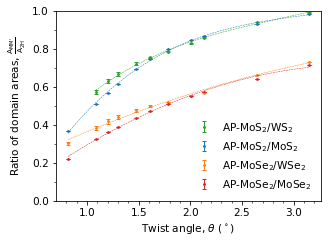

In [10]:
from matplotlib.ticker import MultipleLocator
fontsize = 8.5+2
plt.rcParams['font.size'] = fontsize
marker='H'
plt.figure(figsize=(4.75,3.5))


prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
plt_colors = {'MoS2/MoS2':colors[0],'MoS2/WS2':colors[2],'MoSe2/MoSe2':colors[3],'MoSe2/WSe2':colors[1]}

for stacking in ['AP']:
    if stacking =='P':
        mpairs = [('Mo','W')]
        marker ='^'
    else:
        mpairs = [('Mo','W'),('Mo','Mo')]
        marker ='H'
        
    for x1 in ['S','Se']:
        
        for m1,m2 in mpairs:
            
            
            if stacking=='AP': 
                if m1==m2 or x1=='Se':
                    iis=[10,12,15,16,18,20,22,25,27,30,40]
                else:
                    iis=[10,12,15,16,18,20,22,25,27,30]
            else:
                iis=[16,18,20,22,25,27,30]

            label = rf'{stacking}-{m1}{x1}$_2$/{m2}{x1}$_2$'
            angles = [twist_angles[ii] for ii in iis]
            dict_data = ratios_dict[f'{stacking}-{m1}{m2}{x1}']
            
            mask = dict_data != 0
            
            means = np.ma.masked_array(dict_data, mask=~mask).mean(axis=1)
            stds = np.ma.masked_array(dict_data, mask=~mask).std(axis=1)
            color = plt_colors[f'{m1}{x1}2/{m2}{x1}2']
            errorplot = plt.errorbar(angles,means,yerr=stds,fmt=marker,label=label,markersize=2,
                        elinewidth=1,capsize=2,capthick=1,barsabove=True,color=color)
        
            if x1=='S':
                npoly=3
            else:
                npoly=2

            poly = np.polyfit(angles,means,npoly)
            poly_angles = np.linspace(min(angles),max(angles),150)
            poly_means = np.polyval(poly,poly_angles)

            plt.plot(poly_angles,poly_means,color=errorplot[0].get_color(),linestyle='--',lw=0.5)

            
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.1))
plt.gca().yaxis.set_minor_locator(MultipleLocator(0.1))
plt.xlabel(r'Twist angle, $\theta\ (^\circ)$ ')
#plt.ylabel(r"$\frac{MM'}{2H}$")
plt.ylabel(r"Ratio of domain areas, $\frac{\mathrm{A_{MM'}}}{\mathrm{A_{2H}}}$")
plt.ylim(0,1)
#plt.xlim(1,2.5)
plt.legend(frameon=False,fontsize=fontsize,loc='lower right')
plt.savefig('domain_ratio.png',dpi=300,facecolor='white',transparent=False,
            bbox_inches='tight',pad_inches=0.02)

plt.show()